<a href="https://colab.research.google.com/github/faizan-tnvr004/AI-Based-Meeting-Transcript-Organizer/blob/main/AI_Deliverable_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

we have divided our work into three chunks

part 1: creating  dataset, building  text cleaning function , encoding labels, TF-IDF vectorization, and  train/test split.

part 2:builds  neural network layer by layer with detailed explanations of ReLU, Dropout, Softmax

part 3:  train  model, plots accuracy/loss curves, builds  TextRank summarizer using NetworkX, evaluates with Precision/Recall/F1, draws  confusion matrix, runs a full end-to-end demo,

In [ ]:
#faizan
#using NLTK to do tokenization
import nltk
nltk.download('punkt')        #sentence/word splitter
nltk.download('punkt_tab')    #updated version of punkt
nltk.download('stopwords')    #list of filler words to ignore
nltk.download('wordnet')      #dictionary for finding word roots


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
#faizan
import pandas as pd
import numpy as np
import re
import json

from datasets import load_dataset

#using this for text processing
from nltk.corpus import stopwords #this is for filler words
from nltk.stem import WordNetLemmatizer #this is to reduce words
from nltk.tokenize import word_tokenize #this is for splitting text

#sklear tools

from sklearn.preprocessing import LabelEncoder #converts text labels to number
from sklearn.feature_extraction.text import TfidfVectorizer #converts text to numerical matrices
from sklearn.model_selection import train_test_split #to split data
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # for measuring
from sklearn.metrics.pairwise import cosine_similarity #measure sentence similarity

#neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential #stacking layers
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.callbacks import EarlyStopping


#graphs
import networkx as nx #for graphs
from sklearn.metrics.pairwise import cosine_similarity #measure sentence similarity

#visualization
import seaborn as sns #statistical plots
import matplotlib.pyplot as plt #core plots

tf.random.set_seed(42)
np.random.seed(42)

print("all libraries imported")
print(f"tensorFlow: {tf.__version__}")


all libraries imported
tensorFlow: 2.19.0


In [ ]:
#faizan
#importing QMSum dataset

import urllib.request
import json

# Define  direct links to  raw GitHub files
repo_urls = {
    'train': 'https://raw.githubusercontent.com/Yale-LILY/QMSum/main/data/ALL/jsonl/train.jsonl',
    'validation': 'https://raw.githubusercontent.com/Yale-LILY/QMSum/main/data/ALL/jsonl/val.jsonl',
    'test': 'https://raw.githubusercontent.com/Yale-LILY/QMSum/main/data/ALL/jsonl/test.jsonl'
}

qmsum = {}

# Open network connections and parse  JSONL files into lists
for split_name, file_url in repo_urls.items():
    with urllib.request.urlopen(file_url) as network_response:
        qmsum[split_name] = [json.loads(line) for line in network_response]

print(f"\nQMSum loaded successfully from GitHub!")
print(f"Splits available: {list(qmsum.keys())}")
print(f"Train records:      {len(qmsum['train'])}")
print(f"Validation records: {len(qmsum['validation'])}")
print(f"Test records:       {len(qmsum['test'])}")

# Inspect  structure of ONE record to understand  format
sample = qmsum['train'][0]
print(f"\nKeys in each record: {list(sample.keys())}")
print(f"Number of transcript turns in first record: {len(sample['meeting_transcripts'])}")
print(f"Number of queries in first record: {len(sample['specific_query_list'])}")

# Show one example query
print("\nExample query from first record:")
query_sample = sample['specific_query_list'][0]  # first query

print(f"  Query: {query_sample['query']}")
print(f"  Relevant spans: {query_sample['relevant_text_span']}")


QMSum loaded successfully from GitHub!
Splits available: ['train', 'validation', 'test']
Train records:      162
Validation records: 35
Test records:       35

Keys in each record: ['topic_list', 'general_query_list', 'specific_query_list', 'meeting_transcripts']
Number of transcript turns in first record: 506
Number of queries in first record: 6

Example query from first record:
  Query: How Did Project Manager and User Interface introduce the prototype of the remote control?
  Relevant spans: [['0', '39']]


In [ ]:
# --- Handcrafted Action Items ---
import random

action_item_sentences = [
    "John will send the revised budget proposal to the finance team by end of day Friday.",
    "Sarah needs to schedule a follow-up meeting with the client before next Wednesday.",
    "The marketing team must prepare the campaign brief and circulate it for review.",
    "Please update the project tracker with the current status of all open tasks.",
    "David is responsible for coordinating with the vendor about the delayed shipment.",
    "The legal team needs to review the contract and flag any compliance issues by Monday.",
    "Emma will consolidate the feedback from all departments into a single report.",
    "Someone needs to book the conference room for the quarterly review session.",
    "The engineering lead should document the new deployment process before the sprint ends.",
    "HR needs to send out the updated leave policy to all employees this week.",
    "Mike will reach out to the three shortlisted candidates and arrange interviews.",
    "The finance team must reconcile last quarter's expenses before the audit.",
    "Please assign a project manager to oversee the migration to the new platform.",
    "The sales team needs to update their pipeline forecasts in the CRM system.",
    "Anna will draft the executive summary and share it with leadership for sign-off.",
    "The IT department should patch all servers before the security audit next month.",
    "James needs to collect the signed NDAs from all external consultants.",
    "We need someone to take ownership of the onboarding documentation update.",
    "The product team must prioritize the bug backlog before the next release cycle.",
    "Rachel will prepare the presentation slides for the investor briefing on Thursday.",
    "The operations team needs to review the current SLA terms with the supplier.",
    "Tom should follow up with the design agency about the brand refresh timeline.",
    "Finance needs to process the pending expense reimbursements before month end.",
    "The compliance officer will prepare the quarterly regulatory report.",
    "Dev needs to deploy the hotfix to production after QA signs off.",
    "The team lead should communicate the new process changes to all team members.",
    "Marketing must localize the campaign materials for the European launch.",
    "The account manager needs to send a proposal to the client by Thursday afternoon.",
    "We need to assign someone to monitor the system metrics after the update.",
    "The project coordinator should update the Gantt chart to reflect the new timeline.",
    "Dr. Smith will submit the revised manuscript to the journal by the end of the month.",
    "The research assistant needs to collect and clean the survey data before next week.",
    "Please distribute the reading list to all graduate students before the seminar.",
    "The lab manager must order the reagents before the current stock runs out.",
    "The committee chair will circulate the draft agenda for approval before Thursday.",
    "Students are required to submit their literature review drafts by next Friday.",
    "The department coordinator needs to book the seminar room for the spring series.",
    "Dr. Lee will reach out to the external reviewer and confirm their availability.",
    "The teaching assistant should upload the lecture recordings to the course portal.",
    "The ethics board submission must be completed and filed within the next two weeks.",
    "The principal investigator needs to sign the grant application before submission.",
    "Research team members should update their progress reports in the shared drive.",
    "The postdoc will prepare the data visualization for the conference presentation.",
    "Someone needs to coordinate travel arrangements for the visiting speaker.",
    "The department must respond to the accreditation committee requests by month end.",
    "The city planner will prepare a detailed impact assessment for the proposed development.",
    "Staff must notify all affected residents about the road closure at least two weeks in advance.",
    "The council administrator needs to file the amended ordinance with the city clerk.",
    "The public works department should inspect the drainage system before the rainy season.",
    "The mayor's office will issue a formal statement addressing the community concerns.",
    "The budget committee must submit its recommendations before the next council session.",
    "The parks department needs to develop a maintenance schedule for the new facilities.",
    "Council members should review the environmental report and submit written comments.",
    "The procurement office will issue the request for proposals for the infrastructure project.",
    "The city attorney must review the proposed zoning changes before the public hearing.",
    "Staff needs to organize the town hall meeting and send invitations to stakeholders.",
    "The transportation department should provide an updated report on traffic congestion.",
    "The clerk's office must archive all meeting minutes from the previous fiscal year.",
    "The housing authority will develop affordable housing guidelines by the next quarter.",
    "Department heads need to submit their budget requests for the upcoming fiscal year.",
    "The backend team needs to refactor the authentication module before the next sprint.",
    "Someone should write unit tests for the newly added payment processing functions.",
    "The DevOps engineer will set up the CI/CD pipeline for the new microservice.",
    "Please create a ticket for the performance regression identified in this week's testing.",
    "The security team must conduct a penetration test before the public launch.",
    "The mobile team needs to fix the crash reported on iOS 17 devices this week.",
    "The architect will document the API design and share it in Confluence.",
    "QA needs to create a full regression test suite for the checkout flow.",
    "The data team will migrate the legacy database to the new schema by end of sprint.",
    "The platform team should investigate the memory leak before the next release.",
    "Someone needs to update the user documentation to reflect the new dashboard layout.",
    "The infrastructure team must increase server capacity before the promotional event.",
    "The UX designer will run usability testing sessions with five participants next week.",
    "Product management needs to finalize the feature specifications for Q3 development.",
    "The analytics team should set up dashboards to monitor post-launch KPIs.",
    "The frontend team will address the accessibility issues flagged in the audit.",
    "Dev needs to update the SDK documentation before releasing version 2.0.",
    "The team must complete the GDPR compliance review for all new data flows.",
    "Someone should integrate the third-party payment gateway into the staging environment.",
    "The release manager will coordinate the go-live checklist with all teams.",
    "The nursing staff must complete the updated infection control training by next Friday.",
    "Dr. Patel will review all pending referrals and prioritize urgent cases this week.",
    "The pharmacy team needs to audit the controlled substance inventory before month end.",
    "The clinical coordinator should schedule follow-up appointments for all discharged patients.",
    "The IT team must configure the new patient management system before go-live.",
    "Staff are required to update their certifications before the accreditation inspection.",
    "The billing department needs to resolve all outstanding insurance claim disputes.",
    "The medical director will prepare the quality improvement report for the board meeting.",
    "The infection control officer must investigate the reported cluster and submit findings.",
    "The training coordinator needs to schedule mandatory safety briefings for all staff.",
    "The project manager will update the risk register and share it with all stakeholders.",
    "Each team lead needs to submit a status update before the weekly sync on Monday.",
    "The procurement team must complete the vendor evaluation by the end of this quarter.",
    "Someone needs to create and distribute meeting notes within 24 hours of each session.",
    "The change management team will develop a communication plan for the system migration.",
    "All team members must complete the mandatory cybersecurity training by end of month.",
    "The project sponsor needs to sign off on the revised scope document this week.",
    "The scrum master should schedule retrospective sessions at the end of each sprint.",
    "The client success team needs to prepare the quarterly business review deck.",
    "Operations must develop a contingency plan for the identified supply chain risks.",
    "We need to assign ownership of the customer feedback analysis to someone on the team.",
    "The next step is for finance to validate the cost estimates in the proposal.",
    "Can someone take the action to investigate the root cause of the system failure.",
    "It is the responsibility of the department head to communicate this change to the team.",
    "The follow-up task is to collect all signatures on the memorandum of understanding.",
    "Before the next meeting someone needs to pull the performance data from the system.",
    "The team has been tasked with reviewing the current vendor contracts for renegotiation.",
    "Marketing should coordinate with the PR agency to align the messaging strategy.",
    "The team agreed that legal would handle the intellectual property review.",
    "The data science team will prototype the recommendation engine by end of quarter.",
    "Human resources must update the job descriptions before posting the new openings.",
    "The board secretary will distribute the board pack at least five days before the meeting.",
    "The compliance team needs to prepare a gap analysis against the new regulations.",
    "The product owner must groom the backlog and reprioritize based on customer impact.",
    "The support team needs to escalate the recurring issue to the engineering team.",
    "The design team must deliver the final mockups to development by Wednesday.",
    "The training team should develop e-learning modules for the new compliance policy.",
    "The account executive needs to submit the renewal proposal before the contract expires.",
    "The technical writer will update the API documentation to reflect the version 3 changes.",
    "The team needs to implement automated monitoring alerts for the production environment.",
    "The manager needs to complete and submit performance appraisals for all direct reports.",
    "The supply chain team should identify alternative suppliers to reduce single-source risk.",
    "The release coordinator will send the go-live communication to all affected users.",
    "The business development team needs to prepare pitch materials for the conference.",
    "The administrator will circulate the draft minutes for approval within 48 hours.",
    "The analytics team should segment the customer data before the targeting exercise.",
    "The IT security team must implement multi-factor authentication across all systems.",
    "The product manager will gather user feedback and synthesize it into actionable insights.",
    "The communications officer will update the website content before the campaign launches.",
    "The project team must submit the final deliverable report to the client by month end.",
    "Someone needs to coordinate logistics for the off-site strategy planning session.",
    "The engineering team should review the technical debt backlog and estimate remediation effort.",
    "The data governance team must establish data quality standards before the system launch.",
    "Finance must prepare the variance analysis report before the budget review meeting.",
    "The onboarding team needs to update the new employee orientation materials.",
    "The customer success team will develop a playbook for handling escalated complaints.",
    "Legal should prepare a summary of the regulatory changes affecting our operations.",
    "The technical team will evaluate three vendor solutions and present a recommendation.",
    "The project coordinator must maintain an up-to-date issues log throughout the project.",
    "The marketing analyst will prepare a competitive benchmarking report by next Tuesday.",
    "The quality assurance team should develop acceptance criteria for all user stories.",
    "The procurement team must obtain at least three quotes before awarding the contract.",
    "The team lead will conduct one-on-one check-ins with all team members this week.",
    "The project manager must obtain written approval from all stakeholders before proceeding.",
    "The finance controller needs to close the books and report results within five business days.",
    "The helpdesk team must update the FAQ page based on the most common support tickets.",
    "The steering committee needs to review and approve the updated project charter.",
    "Risk management should update the mitigation strategies for all high-priority risks.",
    "The business analyst needs to map the current-state process before redesign begins.",
    "Someone must update the lessons-learned log after each project milestone.",
    "The communications team will send the stakeholder newsletter by Friday.",
    "The integration team must complete end-to-end testing before the system goes live.",
    "The quality assurance team needs to sign off on the release before it goes to production.",
    "The department head will submit the staffing request to administration by Tuesday.",
    "The outreach team must follow up with patients who missed their scheduled appointments.",
    "The lab must process the backlog of pending samples before the weekend.",
    "The facilities team should inspect all emergency exits and fire suppression systems.",

      "The team needs to review the latest customer feedback and identify improvement areas.",
"The project manager will prepare a revised timeline after assessing current delays.",
"The finance team must verify all outstanding invoices before closing the quarter.",
"Someone needs to document the meeting outcomes and circulate them to stakeholders.",
"The HR department should update the employee handbook with the new policies.",
"The engineering team will fix the critical bugs identified during testing.",
"The marketing team needs to finalize the content calendar for next month.",
"The support team must respond to all pending tickets within 24 hours.",
"The product manager will gather requirements for the upcoming feature release.",
"The QA team should validate the fixes before deployment to production.",
"The data team needs to clean and preprocess the dataset before analysis.",
"The operations team must ensure all systems are running smoothly during peak hours.",
"Someone should follow up with the client regarding their feedback on the proposal.",
"The design team will create wireframes for the new user interface.",
"The backend team needs to optimize database queries for better performance.",
"The frontend team must fix UI inconsistencies reported by users.",
"The IT team should update all systems with the latest security patches.",
"The team lead will assign tasks for the next sprint.",
"The analytics team needs to generate reports for the weekly review meeting.",
"The compliance team must ensure adherence to all regulatory requirements.",
"The sales team should update client records in the CRM system.",
"The training team will prepare onboarding materials for new employees.",
"The product team needs to review feature requests and prioritize them.",
"The support manager must analyze recurring issues and suggest solutions.",
"The development team should refactor legacy code for better maintainability.",
"The team needs to prepare documentation for the API endpoints.",
"The operations manager will review the workflow for process improvements.",
"The marketing team must analyze campaign performance metrics.",
"The finance department needs to approve the budget allocation.",
"The project team should identify risks and create mitigation plans.",
"The team lead will conduct a review meeting at the end of the sprint.",
"The QA engineer must create test cases for the new features.",
]

# Top-up Action Items to reach 400


extra_action_items = [
    "The team lead needs to allocate resources for the upcoming proof-of-concept project.",
    "The communications officer will update the website content before the campaign launches.",
    "The project team must submit the final deliverable report to the client by month end.",
    "Someone needs to coordinate logistics for the off-site strategy planning session.",
    "The head of operations will present the cost-reduction proposals at the board meeting.",
    "The engineering team should review the technical debt backlog and estimate remediation effort.",
    "The data governance team must establish data quality standards before the system launch.",
    "The team will conduct a lessons-learned session and document findings after the project.",
    "Finance must prepare the variance analysis report before the budget review meeting.",
    "The onboarding team needs to update the new employee orientation materials.",
    "The customer success team will develop a playbook for handling escalated complaints.",
    "The partnerships team needs to finalize the terms of the co-marketing agreement.",
    "Legal should prepare a summary of the regulatory changes affecting our operations.",
    "The technical team will evaluate three vendor solutions and present a recommendation.",
    "The project coordinator must maintain an up-to-date issues log throughout the project.",
    "The marketing analyst will prepare a competitive benchmarking report by next Tuesday.",
    "The quality assurance team should develop acceptance criteria for all user stories.",
    "The procurement team must obtain at least three quotes before awarding the contract.",
    "Someone needs to update the organizational chart to reflect the recent restructuring.",
    "The team lead will conduct one-on-one check-ins with all team members this week.",
    "The project manager must obtain written approval from all stakeholders before proceeding.",
    "The customer experience team will map the end-to-end customer journey by next month.",
    "The finance controller needs to close the books within five business days.",
    "The helpdesk team must update the FAQ page based on the most common support tickets.",
    "The steering committee needs to review and approve the updated project charter.",
    "Risk management should update the mitigation strategies for all high-priority risks.",
    "The business analyst needs to map the current-state process before redesign begins.",
    "Someone must update the lessons-learned log after each project milestone.",
    "The communications team will send the stakeholder newsletter by Friday.",
    "The integration team must complete end-to-end testing before the system goes live.",
    "The quality assurance team needs to sign off on the release before production.",
    "The department head will submit the staffing request to administration by Tuesday.",
    "The outreach team must follow up with patients who missed their scheduled appointments.",
    "The lab must process the backlog of pending samples before the weekend.",
    "The facilities team should inspect all emergency exits and fire suppression systems.",
    "HR needs to complete the performance review cycle for all clinical staff by March.",
    "The supply chain manager must identify backup suppliers before the contract expires.",
    "The scrum master will document all blockers raised during the retrospective session.",
    "The release manager needs to prepare the rollback plan before the deployment window.",
    "The security officer must conduct a risk assessment before onboarding the new vendor.",
    "The team needs to migrate all legacy data before the old system is decommissioned.",
    "The product team should run A/B tests on the new checkout flow before full rollout.",
    "The client manager will prepare a post-mortem report after the incident is resolved.",
    "The training team needs to deliver onboarding sessions for all new hires this month.",
    "The infrastructure lead should document the disaster recovery procedures this sprint.",
    "The data analyst needs to validate the pipeline outputs before the report goes live.",
    "The operations team must update the runbook to reflect the new deployment process.",
    "Someone should schedule a knowledge transfer session before the contractor leaves.",
    "The team needs to define SLAs for the new support tier before the launch date.",
    "The project board must review and sign off on the business case by end of quarter.",
    "The account team needs to prepare renewal documentation for all contracts expiring this year.",
    "The development team should spike the authentication issue and report findings by Wednesday.",
    "The marketing team must get legal approval on all campaign materials before publishing.",
    "The site reliability team needs to set up alerting for the new microservices cluster.",
    "The finance team should reconcile all intercompany transactions before the audit begins.",
    "The HR business partner needs to facilitate the team restructuring discussion this week.",
    "The clinical team must submit the adverse event report to the regulator within 72 hours.",
    "The council officer needs to prepare briefing notes for the committee by next Thursday.",
    "The budget holder must approve all purchase orders above five thousand dollars.",
    "The transformation team should present the change impact assessment to leadership.",
    "The data protection officer needs to conduct a privacy impact assessment for the new system.",
    "The project team must hold a kickoff meeting with all stakeholders before work begins.",
    "The procurement lead should shortlist vendors and arrange demos for next week.",
    "The team needs to update all API endpoints to use the new authentication standard.",
    "The workshop organizer must send pre-reading materials to all participants in advance.",
    "The delivery manager needs to track velocity and flag any risks to the release date.",
    "The compliance team must complete the internal audit and submit findings to the board.",
    "The support team needs to create escalation procedures for priority one incidents.",
    "The architect should review the proposed database schema before development begins.",
    "The business owner needs to define acceptance criteria before the sprint planning session.",
    "The analytics lead must present dashboard mockups to stakeholders before development.",
    "The team should document all API breaking changes in the release notes before shipping.",
    "The operations director needs to approve the updated business continuity plan.",
    "The legal team must file all necessary permits before the construction project begins.",
    "The brand team should review all external communications before they are published.",
    "The finance director needs to present the revised budget to the board next Monday.",
    "The project manager should circulate the updated RACI matrix to all team members.",
    "The technical lead must review the architecture proposal and provide written feedback.",
    "The customer insights team needs to run focus groups before the product redesign begins.",
    "The data team should implement row-level security before granting dashboard access.",
    "The team needs to complete penetration testing before the ISO certification audit.",
    "The product designer must conduct user interviews and synthesize findings this week.",
    "The release team should prepare deployment scripts and test them in staging first.",
    "The sales director needs to review and approve the updated commission structure.",
    "The risk committee must assess the new vendor's financial stability before contracting.",
    "The team lead should escalate the resourcing gap to the programme manager immediately.",
    "The transformation lead needs to update the benefits realization tracker monthly.",
    "The marketing coordinator must brief the agency on the new brand guidelines.",
    "The security team needs to rotate all production credentials before the end of the week.",
    "The project team should hold a mid-point review with the client to validate direction.",
    "The data engineer needs to build the ingestion pipeline before the analysts can start.",
    "The HR team must circulate the updated disciplinary policy for employee sign-off.",
    "The team needs to produce a test plan covering all edge cases before QA begins.",
    "The delivery lead should report overall programme status to the steering group weekly.",
    "The product manager needs to get sign-off on the revised roadmap from all stakeholders.",
    "The legal team should review all third-party data sharing agreements this quarter.",
    "The technical architect must produce an infrastructure sizing document before procurement.",
    "The team should set up a shared repository for all project documentation immediately.",
    "The change manager needs to assess the people impact before the system goes live.",
    "The finance team must produce cash flow forecasts for the next three quarters.",
    "The project sponsor needs to remove the identified blocker before the next sprint begins.",
    "The team lead should organise a team-building session to address the morale issues.",
    "The business development manager needs to submit the tender response before the deadline.",
    "The operations team must complete the capacity planning exercise before Q4 begins.",
    "The communications lead should draft the internal announcement before the decision is shared.",
    "The testing team needs to execute the full regression suite before the release window.",
    "The data steward must classify all datasets according to the new data governance policy.",
    "The programme manager should produce a consolidated risk report for the board.",
    "The account director needs to present the renewal strategy to the client next Tuesday.",
    "The team must decommission the legacy servers after the migration is validated.",
    "The product owner should update the backlog with the new regulatory requirements.",
    "The facilities manager needs to arrange deep cleaning of all office spaces this weekend.",
    "The engineering manager should present the technical roadmap to the leadership team.",
    "The vendor manager needs to issue a formal notice of breach to the underperforming supplier.",
    "The team should complete the impact assessment before any changes are made to production.",
    "The HR lead must coordinate with payroll to ensure the salary changes are processed.",
    "The compliance officer needs to brief all staff on the updated anti-bribery policy.",
    "The data science team must validate model outputs against the holdout set before deployment.",
    "The project team should produce a lessons-learned report within two weeks of go-live.",
    "The commercial team needs to finalise pricing before the proposal goes to the client.",
    "The infrastructure team must provision the new environments before development starts.",
    "The programme director should escalate the budget overrun to the executive committee.",
    "The team needs to agree on a branching strategy before the next development sprint.",
    "The marketing team must produce localised content for each target market before launch.",
    "The clinical lead needs to review and approve all patient-facing materials before release.",
    "The team should implement logging and monitoring before deploying to production.",
    "The business analyst must validate the requirements with the end users before sign-off.",
    "The project manager needs to update the project plan to reflect the revised timeline.",
    "The team lead should arrange handover documentation before the key resource leaves.",
    "The data team must anonymise all personal data before sharing it with external parties.",
    "The QA lead needs to sign off the test results before the product can be released.",
    "The commercial director should review all contracts before they are sent to the client.",
    "The team must complete the security review before the application goes to production.",
    "The scrum team needs to refine the user stories before the next sprint planning session.",
    "The operations team should update the incident response playbook after each major incident.",
    "The programme manager must track and report on all milestones weekly.",
    "The finance team needs to submit the monthly management accounts within ten working days.",
    "The team lead should brief the wider team on the outcome of the leadership meeting.",
    "The project team must complete the user acceptance testing before the system goes live.",
    "The vendor should provide a remediation plan within five business days of the audit.",
    "The data team needs to refresh the dashboards before the executive review on Friday.",
    "The design team should incorporate feedback into the final design.",
"The backend team needs to implement caching for faster response times.",
"The frontend team must ensure cross-browser compatibility.",
"The IT support team should resolve all high-priority incidents.",
"The product owner will review backlog items before sprint planning.",
"The team needs to ensure data integrity across all systems.",
"The marketing manager must approve the final campaign creatives.",
"The engineering team should monitor system performance post-deployment.",
"The team needs to update the project documentation regularly.",
"The HR team must schedule performance evaluations for employees.",
"The finance team should track expenses against the budget.",
"The development team needs to conduct code reviews before merging changes.",
"The QA team must automate regression test cases.",
"The product team should analyze user behavior data.",
"The support team needs to escalate unresolved issues.",
"The design team must ensure consistency in branding.",
"The operations team should streamline internal processes.",
"The IT team needs to back up all critical data.",
"The team lead must ensure deadlines are met.",
"The analytics team should validate data accuracy.",
"The project manager needs to update stakeholders on progress.",
"The marketing team must coordinate with external agencies.",
"The development team should fix performance bottlenecks.",
"The QA team needs to verify bug fixes.",
"The HR department must handle employee grievances.",
"The finance team should reconcile bank statements.",
"The team needs to prepare for the upcoming audit.",
"The engineering team must review system architecture.",
"The product team should finalize the release plan.",
"The support team needs to improve response times.",
"The design team must deliver high-fidelity prototypes.",
"The operations team should monitor supply chain performance.",
"The IT team must ensure network security.",
"The marketing team should optimize SEO strategies.",
"The sales team needs to follow up on leads.",
"The QA team must document test results.",
"The development team should update dependencies.",
"The analytics team needs to create dashboards.",
"The project manager must allocate resources efficiently.",
"The HR team should organize training sessions.",
"The finance team needs to prepare financial statements.",
"The team must ensure compliance with company policies.",
"The engineering team should conduct system testing.",
"The product team needs to gather user feedback.",
"The support team must resolve escalated issues.",
"The design team should update design guidelines.",
"The operations team must ensure timely deliveries.",
"The IT team should maintain system uptime.",
"The marketing team needs to track ROI.",
"The sales team must close pending deals.",
"The QA team should perform load testing.",
"The development team needs to implement new features.",
"The analytics team must interpret data trends.",
"The project team should review project milestones.",
"The HR team needs to update employee records.",
"The finance team must monitor cash flow.",
"The team should improve internal communication.",
"The engineering team needs to enhance system scalability.",
"The product team must refine product roadmap.",
"The support team should gather customer feedback.",
"The design team needs to test usability.",
"The operations team must reduce operational costs.",
"The IT team should manage system updates.",
"The marketing team must align with business goals.",
"The sales team should improve conversion rates.",
"The QA team must ensure product quality.",
"The development team should maintain coding standards.",
"The analytics team needs to report insights regularly.",
    "Can someone follow up with the vendor about the delay?",
"Let's make sure the updated document is shared before tomorrow.",
"Please have the draft ready for review by the end of the day.",
"Who is taking ownership of the onboarding process update?",
"We should revisit this after collecting more data.",
"Ensure that all dependencies are resolved before deployment.",
"The next step is getting approval from the compliance team.",
"Kindly double-check the figures before sending the report.",
"We need clarity on who will handle the client communication.",
"Action: finalize the presentation and send it out.",
"Make sure the issue is logged in the tracking system.",
"Follow up is required on the pending invoices.",
"Someone should take charge of documenting this process.",
"Let's assign this task to the backend team.",
"This needs to be escalated if not resolved today.",
"Coordinate with design before making any UI changes.",
"Don't forget to update the shared dashboard.",
"Please confirm once the task is completed.",
"We'll need a summary of this discussion by tomorrow.",
"Can this be completed before the next sprint?",
"Action item is to review and approve the budget.",
"Ensure stakeholders are informed about the change.",
"Let's get feedback from users before proceeding.",
"This should be prioritized for the upcoming release.",
"Assign someone to monitor this after deployment.",
"We need to validate the results before publishing.",
"Please arrange a follow-up meeting with the client.",
"Document the issue and proposed solution clearly.",
"Check if this aligns with current business goals.",
"Let's not proceed until we have confirmation.",
"Prepare a backup plan in case this fails.",
"Someone needs to verify the data accuracy.",
"Ensure this is compliant with company policies.",
"Kindly update the timeline accordingly.",
"Follow up with the legal team for clearance.",
"We should test this scenario before rollout.",
"Make sure logs are properly recorded.",
"Action: investigate the root cause of the error.",
"Can we assign this to someone from QA?",
"Please ensure all comments are addressed.",
"We need a final sign-off before moving ahead.",
"Coordinate across teams to avoid duplication.",
"Let's make this part of the next sprint backlog.",
"Someone should clean up the outdated entries.",
"Ensure proper documentation is maintained.",
"Please take care of the pending approvals.",
"We should collect more user feedback on this.",
"Assign priority based on impact and urgency.",
"Let's finalize the requirements by tomorrow.",
"This needs further analysis before decision.",
"Ensure the system is stable post-update.",
"Please notify the team once deployed.",
"We need to close this before the deadline.",
"Someone should review the changes carefully.",
"Let's capture this in the meeting notes.",
"Make sure testing covers edge cases.",
"Follow up with stakeholders for input.",
"Ensure proper handover is completed.",
"Let's review this again in the next meeting.",
"This requires coordination with external teams.",
"Please escalate if blockers persist.",
"Assign a point of contact for this task.",
"Ensure version control is maintained.",
"Someone needs to audit the current setup.",
"Let's align this with the overall roadmap.",
"Make sure all requirements are documented.",
"We should track progress regularly.",
"Please confirm availability before scheduling.",
"This should be addressed immediately.",
"Ensure the solution is scalable.",
"Let's validate assumptions before proceeding.",
"Someone should monitor performance metrics.",
"Please update everyone on the progress.",
"We need to ensure consistency across modules.",
"Let's get this reviewed by a senior member.",
"Ensure proper testing before release.",
"Someone should handle the client queries.",
"Please check for any missing dependencies.",
"This needs to be logged as a high-priority task.",
"Ensure data is backed up before changes.",
"Let's include this in the risk assessment.",
"Someone should verify the configuration.",
"Please prepare a quick summary report.",
"We should review compliance requirements.",
"Ensure the deployment checklist is followed.",
"Let's assign deadlines for each task.",
"Someone needs to track this issue closely.",
"Please make necessary corrections.",
"This requires immediate attention.",
"Ensure all stakeholders are aligned.",
"Let's finalize this after discussion.",
"Someone should draft the communication.",
"Please validate inputs before processing.",
"We need to document this for future reference.",
"Ensure the task is completed within timeline.",
"Let's double-check everything before submission.",
"Someone should coordinate testing efforts.",
"Please update the status in the tracker.",
"We should avoid delays in this phase.",
    "Circle back with the client regarding their concerns.",
"Have this wrapped up before the end of the week.",
"Ownership for this still needs to be decided.",
"Let’s not lose track of this item.",
"Get confirmation from finance on the budget.",
"Push this forward once dependencies are cleared.",
"Check whether this has already been addressed.",
"Someone needs to close the loop on this.",
"Add this to the action tracker.",
"Revisit once the numbers are finalized.",
"Ensure alignment before moving ahead.",
"Flag this if anything changes.",
"Have the details been verified?",
"Let’s keep this on the radar.",
"Drive this to completion.",
"Confirm with the external partner.",
"Escalation might be required here.",
"Keep monitoring this closely.",
"Is someone already handling this?",
"Add a note in the documentation.",
"Loop in the relevant stakeholders.",
"Capture the key takeaways.",
"Follow through on this commitment.",
"Make sure nothing is missed.",
"Get clarity on the requirements.",
"Take this offline if needed.",
"Someone should take the lead here.",
"Let’s break this into smaller tasks.",
"Ensure this is properly tracked.",
"Push for an update by tomorrow.",
"Double-check before submission.",
"Raise a ticket for this issue.",
"Keep everyone updated.",
"Don’t let this slip.",
"Make progress visible.",
"Confirm timelines with the team.",
"Close this before the next review.",
"Have we assigned an owner?",
"Document any changes made.",
"Ensure consistency across outputs.",
"Move this to high priority.",
"Let’s validate the approach.",
"Track this item carefully.",
"Prepare for follow-up discussion.",
"Get inputs from the product side.",
"Align this with business goals.",
"Review once more before approval.",
"Capture action points clearly.",
"Someone should review the logs.",
"Update the roadmap accordingly.",
"Make sure the fix is tested.",
"Recheck assumptions.",
"Coordinate efforts across teams.",
"Take ownership and drive this.",
"Escalate if blocked.",
"Keep this moving forward.",
"Ensure deadlines are realistic.",
"Review dependencies carefully.",
"Let’s finalize ownership.",
"Confirm readiness before launch.",
"Follow up without delay.",
"Make sure feedback is incorporated.",
"Check progress regularly.",
"Ensure smooth handoff.",
"Add this to sprint goals.",
"Push updates to the repository.",
"Verify integration points.",
"Make sure stakeholders agree.",
"Re-evaluate if needed.",
"Track deliverables closely.",
"Clarify expectations.",
"Keep communication open.",
"Ensure quality standards are met.",
"Have this reviewed by QA.",
"Follow best practices here.",
"Get sign-off from management.",
"Ensure everything is aligned.",
"Don’t proceed without validation.",
"Make sure this is scalable.",
"Review edge cases.",
"Check for regressions.",
"Ensure nothing breaks.",
"Coordinate testing schedules.",
"Get the final draft ready.",
"Review the impact of this change.",
"Ensure proper versioning.",
"Monitor performance post-release.",
"Check logs after deployment.",
"Keep backups ready.",
"Verify system stability.",
"Document lessons learned.",
"Capture risks involved.",
"Mitigate potential issues.",
"Ensure smooth execution.",
"Keep timelines in check.",
"Prepare for contingencies.",
"Ensure readiness across teams.",
"Track milestones carefully.",
"Ensure transparency.",
"Keep the workflow clean.",
"Validate all inputs.",
"Review outputs thoroughly.",
"Check system compatibility.",
"Ensure proper configuration.",
"Review deployment plan.",
"Confirm environment setup.",
"Verify access permissions.",
"Ensure data integrity.",
"Track anomalies.",
"Flag inconsistencies.",
"Investigate unusual behavior.",
"Ensure audit readiness.",
"Review compliance standards.",
"Document audit trail.",
"Ensure traceability.",
"Confirm all requirements met.",
"Check for missing items.",
"Validate final output.",
"Prepare for handover.",
"Ensure documentation is complete.",
"Keep stakeholders informed.",
"Confirm delivery timelines.",
"Review contractual obligations.",
"Ensure service quality.",
"Track customer feedback.",
"Act on feedback quickly.",
"Ensure continuous improvement.",
"Review metrics regularly.",
"Track KPIs.",
"Ensure targets are met.",
"Align with strategic goals.",
"Ensure execution discipline.",
"Drive accountability.",
"Maintain consistency.",
"Review performance gaps.",
"Take corrective action.",
"Ensure operational efficiency.",
"Keep processes streamlined.",
"Monitor resource usage.",
"Optimize where possible.",
"Ensure cost efficiency.",
"Review budget impact.",
"Track expenses carefully.",
"Ensure financial accuracy.",
"Confirm billing details.",
"Follow up on payments.",
"Ensure vendor coordination.",
"Track supplier performance.",
"Ensure timely delivery.",
"Monitor service levels.",
"Ensure contract compliance.",
"Keep escalation paths clear.",
"Ensure issue resolution.",
"Track support tickets.",
"Ensure customer satisfaction.",
"Maintain service continuity.",
"Prepare incident reports.",
"Ensure quick recovery.",
"Review incident logs."
"Ensure proper review before approval."
]
messy_action_items = [
    # Will / gonna
    "yeah so uh John's gonna send that over by like end of week right",
    "okay so we we will need someone to uh update the tracker before next standup",
    "I think Sarah will handle the client email yeah she said she would",
    "so basically uh the dev team will push that fix once QA signs off",
    "right so Mike's gonna reach out to the vendor about the delay",
    "we said we'll circle back on that so uh someone needs to own it",
    "okay so I I will prepare the slides for Thursday's thing",
    "yeah Tom said he'll look into the billing issue this week",
    "so the legal team will review it and uh flag anything before Monday",
    "I think we agreed that uh Rachel will consolidate all the feedback",

    # Needs to / need to
    "okay so someone needs to book that room like today ideally",
    "yeah the IT guys need to patch those servers before the audit thing",
    "so we need to uh assign an owner for this otherwise it'll just sit",
    "the PM needs to update the Gantt chart to like reflect the new dates",
    "yeah uh HR needs to send out that policy update this week",
    "someone needs to follow up with the client we can't just leave it",
    "okay so the finance team needs to reconcile those expenses before month end",
    "we need to get sign off from management before we proceed with that",
    "uh the QA lead needs to run load testing before we ship this",
    "yeah so ops needs to review the SLA terms with the supplier",

    # Should
    "I think David should coordinate with the vendor on that",
    "so the compliance officer should prepare that report by quarter end",
    "yeah uh the account manager should send the proposal by Thursday",
    "okay the engineering lead should document the deployment process",
    "I think James should collect the NDAs from the external consultants",
    "so uh the design team should probably localize the campaign materials",
    "yeah the teaching assistant should upload those recordings to the portal",
    "uh Emma should draft that executive summary and share it with leadership",
    "the postdoc should prepare the data visualization for the conference",
    "so the department coordinator should book the seminar room for spring",

    # Can you / could you
    "uh can you send me that report before the end of day",
    "yeah could you just follow up with them on that",
    "okay can someone prepare a brief for this for like next Wednesday",
    "can you check with the vendor what the timeline looks like",
    "yeah could you update the project status in the system",
    "uh can you reach out to those candidates and arrange the interviews",
    "okay so can someone just review this contract and flag anything weird",
    "could you prepare the quarterly review slides before Thursday",
    "uh can you coordinate travel for the visiting speaker",
    "can you just double check those numbers before we submit",

    # Let's / we should / we need
    "let's make sure someone follows up on that before the next sprint",
    "we should assign this to someone today it's been sitting too long",
    "uh let's get the budget request submitted before end of month",
    "we need to make sure the onboarding docs are updated",
    "let's have someone monitor the system metrics after the update goes out",
    "we should circulate the agenda before Thursday for approval",
    "uh let's get someone to take ownership of the migration",
    "we need to respond to the accreditation committee before month end",
    "let's make sure the hotfix gets deployed after QA signs off",
    "we should get that proposal out to the client ASAP",

    # Deadline bearing
    "okay so that needs to be done by end of week no later",
    "uh this has to go out before the Monday morning meeting",
    "yeah we need that submitted by next Friday at the latest",
    "okay so by end of quarter this should be wrapped up",
    "uh can we get this done before the release cycle closes",
    "yeah this needs to land before the sprint ends",
    "so by tomorrow EOD someone should have looked at this",
    "uh we need this before the security audit next month",
    "okay so the deadline is Thursday so someone needs to own this now",
    "this has to be filed before the next council session",

    # Follow up
    "okay so uh we need to follow up with the design agency on that",
    "yeah someone needs to follow up on the pending reimbursements",
    "uh can we make sure someone follows up with the external reviewer",
    "so the account manager needs to follow up on the proposal status",
    "yeah we said we'd follow up on this and uh I don't think anyone did",
    "okay so follow up with the three candidates and arrange interviews",
    "uh we need to follow up with the client before Wednesday",
    "can someone follow up on the support ticket that's been open since last week",
    "so someone needs to follow up with the supplier about the delay",
    "okay uh just follow up with the committee and confirm their availability",

    # Assigned with name + filler
    "so uh Anna you're taking the executive summary right",
    "okay Mike I think you said you'd handle the vendor coordination",
    "yeah so Rachel you're on the presentation slides for Thursday",
    "uh Tom can you just take care of the brand refresh timeline",
    "okay so James you're collecting the NDAs from the consultants",
    "yeah Emma you said you'd consolidate that feedback right",
    "so David I think you're owning the vendor shipment issue",
    "uh Sarah can you schedule the follow up with the client",
    "okay so the engineering lead uh I think that's you Alex you're documenting the deployment",
    "so uh whoever owns the CRM needs to update the pipeline forecasts",

    # Passive / group assignment
    "so the marketing team is responsible for the campaign brief",
    "okay the legal team needs to review this and flag compliance issues",
    "uh the IT department should patch all servers before the audit",
    "so the operations team needs to review those SLA terms",
    "the finance team must process the pending reimbursements before month end",
    "okay the research team should update their progress reports in the shared drive",
    "so the product team needs to prioritize the bug backlog before release",
    "the HR team needs to get that policy update out to everyone",
    "okay so the procurement office will issue the RFP for the infrastructure project",
    "the city attorney must review the zoning changes before the public hearing",

    # Informal / fragmented
    "someone needs to own this we can't just leave it",
    "uh okay who's taking this one we need a name",
    "so this needs an owner by end of today",
    "yeah uh let's not let this slip someone needs to track it",
    "okay so just to confirm uh you're taking this right",
    "uh this is a blocker so someone needs to resolve it today",
    "yeah so just to be clear this is on you to follow through",
    "okay so before we wrap up who owns this action",
    "uh let's just make sure this doesn't fall through the cracks",
    "so this needs to get done before we can move forward",

    # Academic / research style
    "uh so Dr Smith will submit the revised manuscript by end of month",
    "okay the research assistant needs to clean the survey data before next week",
    "uh can someone distribute the reading list to the graduate students",
    "so the lab manager needs to order the reagents before stock runs out",
    "okay the committee chair will circulate the draft agenda before Thursday",
    "uh students are required to submit their lit review drafts by next Friday",
    "so the ethics board submission needs to be filed within the next two weeks",
    "okay the PI needs to sign the grant application before it goes in",
    "uh the postdoc will prepare the data viz for the conference presentation",
    "so someone needs to coordinate travel for the visiting speaker",

    # Government / council style
    "uh the city planner will prepare an impact assessment for the proposed development",
    "okay staff must notify affected residents about the road closure two weeks in advance",
    "so the council administrator needs to file the amended ordinance with the city clerk",
    "uh the public works department should inspect the drainage system before rainy season",
    "okay the budget committee must submit its recommendations before the next council session",
    "so the parks department needs to develop a maintenance schedule for the new facilities",
    "uh the procurement office will issue the RFP for the infrastructure project",
    "okay the clerk's office must archive all meeting minutes from the previous fiscal year",
    "so department heads need to submit budget requests for the upcoming fiscal year",
    "uh the housing authority will develop affordable housing guidelines by next quarter",

    # Hesitant / uncertain speaker
    "I think uh someone should look into this maybe by end of week",
    "yeah so I mean someone needs to uh handle the client outreach",
    "uh I guess we could have the dev team look at this um before Friday",
    "so I think we agreed that uh the PM would update the roadmap",
    "yeah I believe John said he'd uh take care of the documentation",
    "uh so maybe Sarah could uh follow up on this I'm not sure",
    "I mean we we should get someone to review the logs after deployment",
    "uh I think it was agreed that uh we'd get the proposal out by Thursday",
    "so I guess the next step is for uh someone to schedule the kickoff",
    "yeah uh I think we need to just assign someone to this today",

    # Mixed / compound
    "okay so Sarah will send the proposal and John will follow up with the client by Thursday",
    "uh so the dev team will fix the bug and QA needs to sign off before we deploy",
    "yeah so I'll prepare the slides and uh Rachel will review them before Thursday",
    "okay so Tom is reaching out to the vendor and Mike is updating the tracker",
    "uh so the legal team reviews it first and then finance needs to sign off",
    "yeah so the research assistant will collect the data and then the postdoc will visualize it",
    "so the PM updates the Gantt chart and then everyone should review it before standup",
    "okay uh I'll draft the summary and someone needs to get it to leadership by EOD",
    "so the IT team patches the servers and then ops monitors for the next 48 hours",
    "yeah so marketing localizes the materials and then the account manager sends them out",

    # Very short / fragmented meeting speech
    "yeah okay you're on that right",
    "uh someone needs to own this action item",
    "okay let's assign this before we close out",
    "yeah so follow up on that today please",
    "uh can we get this done by end of sprint",
    "okay so who's taking this one",
    "yeah this needs to be done before Monday",
    "uh just make sure someone tracks this",
    "okay so you'll send that over right",
    "yeah just follow up on that and let us know",
]

# Append to existing df_action
df_actions = pd.DataFrame({'sentence': action_item_sentences, 'label': 'Action Item'})
df_action_extra = pd.DataFrame({'sentence': extra_action_items, 'label': 'Action Item'})
df_actions_messy = pd.DataFrame({'sentence': messy_action_items,'label': 'Action Item'})

df_actions = pd.concat([df_actions, df_action_extra], ignore_index=True)
df_actions = pd.concat([df_actions, df_actions_messy], ignore_index=True)

print(f"Total Action Items now: {len(df_actions)}")




Total Action Items now: 806


In [ ]:


DECISION_KEYWORDS = [
    'decide', 'decided', 'decision', 'agree', 'agreed', 'agreement',
    'approve', 'approved', 'resolve', 'resolved', 'conclude', 'concluded',
    'confirm', 'confirmed', 'choose', 'chose', 'finalize', 'finalized',
    'vote', 'voted', 'settle', 'settled'
]

def extract_decisions_and_discussion(dataset_split):
    rows = []
    for record in dataset_split:
        turns   = record['meeting_transcripts']
        queries = record['specific_query_list']
        turn_labels = ['Discussion'] * len(turns)

        for q in queries:
            query_lower = q.get('query', '').lower()
            spans = q.get('relevant_text_span', [])
            if any(kw in query_lower for kw in DECISION_KEYWORDS):
                for span in spans:
                    try:
                        start = int(span[0])
                        end   = int(span[1])
                        for i in range(start, min(end + 1, len(turns))):
                            turn_labels[i] = 'Decision'
                    except (ValueError, IndexError):
                        continue

        for i, turn in enumerate(turns):
            content = turn.get('content', '').strip()
            if len(content.split()) >= 5:
                rows.append({'sentence': content, 'label': turn_labels[i]})
    return pd.DataFrame(rows)

print("Extracting from QMSum...")
df_qmsum = pd.concat([
    extract_decisions_and_discussion(qmsum['train']),
    extract_decisions_and_discussion(qmsum['validation']),
    extract_decisions_and_discussion(qmsum['test'])
], ignore_index=True)

df_decisions  = df_qmsum[df_qmsum['label'] == 'Decision']
df_discussion = df_qmsum[df_qmsum['label'] == 'Discussion']
print(f"QMSum Decisions:  {len(df_decisions):,}")
print(f"QMSum Discussion: {len(df_discussion):,}")
print(f"Total Action Items now: {len(df_actions)}")




# --- Proportional CAP sampling ---
MAX_CAP = 1000  # optional hard upper limit per class

# Count available examples
class_counts = {
    'Decision': len(df_decisions),
    'Discussion': len(df_discussion),
    'Action': len(df_actions)
}

# Determine proportional caps
total_available = sum(class_counts.values())
proportional_caps = {}

#action cap
proportional_caps['Action'] = 700
proportional_caps['Decision'] =700
proportional_caps['Discussion'] =700



# Sample
df_balanced = pd.concat([
    df_decisions.sample(n=proportional_caps['Decision'], random_state=42),
    df_discussion.sample(n=proportional_caps['Discussion'], random_state=42),
    df_actions.sample(n=proportional_caps['Action'], random_state=42),
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

# Stats
print(f"\n{'='*45}")
print(f"FINAL BALANCED DATASET")
print(f"{'='*45}")
print(df_balanced['label'].value_counts())
print(f"\nTotal sentences: {len(df_balanced)}")

Extracting from QMSum...
QMSum Decisions:  3,931
QMSum Discussion: 72,223
Total Action Items now: 806

FINAL BALANCED DATASET
label
Discussion     700
Decision       700
Action Item    700
Name: count, dtype: int64

Total sentences: 2100


In [ ]:
#hussain

stepWords = set(stopwords.words('english')) #common useless words like ", is, and" (we remove m)
lemmatizer = WordNetLemmatizer()            #converts words to ir base form such as running-> run

def clean(text): #returns a clean lemmatized string for TF-IDF

   # Step 1: Remove speaker prefixes (e.g. "Project Manager:", "A:", "PM:")
   # Pattern: word(s) followed by a colon at  start of string

   text = re.sub(r'^[A-Za-z][\w\s\.]*:\s*', '', text)

   text = text.lower()

   # Step 3: Remove timestamps (e.g. [00:12:45], (10:30am))
   text = re.sub(r'\[\d{1,2}:\d{2}(?::\d{2})?\]', '', text)
   text = re.sub(r'\(\d{1,2}:\d{2}(?:am|pm)?\)', '', text)

   # Step 4: Remove non-verbal cues in brackets (e.g. [laughter], [inaudible])
   text = re.sub(r'\[.*?\]', '', text)
   text = re.sub(r'\(.*?\)', '', text)

   # Step 5: Remove punctuation and special characters
   text = re.sub(r'[^a-z\s]', '', text)

   # Step 6: Remove extra whitespace
   text = re.sub(r'\s+', ' ', text).strip()

   # Step 7: Tokenize
   tokens = word_tokenize(text)

   # Step 8: Remove stopwords and lemmatize
   cleaned = [
       lemmatizer.lemmatize(w)
       for w in tokens
       if w not in stepWords and len(w) > 1
    ]

   return ' '.join(cleaned)


# --- Verify on a real QMSum-style sentence ---
test_input = "Project Manager: [00:03:22] Okay, so we've DECIDED to use Python for  backend implementation."
print(f"Original: {test_input}")
print(f"Cleaned:  {clean(test_input)}")

print("\nApplying to full dataset...")
df_balanced['cleaned'] = df_balanced['sentence'].apply(clean)

# Remove rows that became empty after cleaning
df_balanced = df_balanced[df_balanced['cleaned'].str.strip().str.len() > 0].reset_index(drop=True)

print(f"\n Cleaning done! Remaining rows: {len(df_balanced):,}")
print("\nBefore vs After (5 examples):")
for i in range(5):
    print(f"  [{df_balanced['label'][i]}]")
    print(f"    Before: {df_balanced['sentence'][i][:80]}")
    print(f"    After:  {df_balanced['cleaned'][i][:80]}")



Original: Project Manager: [00:03:22] Okay, so we've DECIDED to use Python for  backend implementation.
Cleaned:  okay weve decided use python backend implementation

Applying to full dataset...

 Cleaning done! Remaining rows: 2,100

Before vs After (5 examples):
  [Discussion]
    Before: Mr.Chair, I will continue on the subject of supplementary unemployment benefits.
    After:  mrchair continue subject supplementary unemployment benefit let remind everyone 
  [Discussion]
    Before: Special colour ? Yeah . No . Special material ?
    After:  special colour yeah special material
  [Decision]
    Before: We all agree on that . Yeah .
    After:  agree yeah
  [Discussion]
    Before: You all uh have the the questionnaire again about uh the after work .
    After:  uh questionnaire uh work
  [Decision]
    Before: But , only difference is uh {vocalsound} the uh the people buying the remote con
    After:  difference uh vocalsound uh people buying remote control get added feature paren

In [ ]:
#Hussain
# --- Label Encoding ---
labelEncoder = LabelEncoder()
df_balanced['encoded_label'] = labelEncoder.fit_transform(df_balanced['label'])

print("Label → Integer mapping:")
for label, code in zip(labelEncoder.classes_, range(len(labelEncoder.classes_))):
    print(f"  '{label}' → {code}")

# Step 1: Split raw text BEFORE vectorizing
X_raw = df_balanced['cleaned'].values
y = df_balanced['encoded_label'].values

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 2: Fit TF-IDF ONLY on training data
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_raw_train).toarray()
X_test  = vectorizer.transform(X_raw_test).toarray()

print(f"\nTF-IDF Matrix shape: {X_train.shape}")
print(f"  → {X_train.shape[0]:,} training sentences")
print(f"  → {X_train.shape[1]:,} features — unigrams + bigrams")
print(f"\nLabels: {np.unique(y)} → {labelEncoder.classes_}")

print("\nDataset Split:")
print(f"  Total:    {len(X_raw):,}")
print(f"  Training: {len(X_train):,} ({len(X_train)/len(X_raw)*100:.0f}%)")
print(f"  Testing:  {len(X_test):,}  ({len(X_test)/len(X_raw)*100:.0f}%)")
print(f"\nEach sample has {X_train.shape[1]} TF-IDF features")
print("\n Phase 0 complete! Text is now a numerical matrix.")

Label → Integer mapping:
  'Action Item' → 0
  'Decision' → 1
  'Discussion' → 2

TF-IDF Matrix shape: (1680, 2000)
  → 1,680 training sentences
  → 2,000 features — unigrams + bigrams

Labels: [0 1 2] → ['Action Item' 'Decision' 'Discussion']

Dataset Split:
  Total:    2,100
  Training: 1,680 (80%)
  Testing:  420  (20%)

Each sample has 2000 TF-IDF features

 Phase 0 complete! Text is now a numerical matrix.


In [ ]:
#Phase 1 starting

#making Neural Network Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
num_classes = len(labelEncoder.classes_)  # 3 categories
input_dim   = X_train.shape[1]            # 5000

model = Sequential([

    # HIDDEN LAYER 1
    # 128 neurons with ReLU (Rectified Linear Unit) activation
    # ReLU: f(x) = max(0, x) — outputs 0 for negative inputs, x for positive
    # This allows  network to learn non-linear decision boundaries
    Dense(128, activation='relu', input_dim=input_dim,
     kernel_regularizer=l2(0.01)),   # L2 penalizes large weights

    # DROPOUT LAYER (Regularization)
    # During training, randomly sets 30% of neuron outputs to 0
    # Forces  network to learn redundant representations → generalizes better
    # IMPORTANT: Dropout is only active during training, NOT during prediction
    Dropout(0.4),

    # HIDDEN LAYER 2
    # 64 neurons — learns higher-level abstract combinations of Layer 1 patterns
    Dense(64, activation='relu',
            kernel_regularizer=l2(0.01)),

    Dropout(0.4),

    # OUTPUT LAYER
    # 3 neurons — one per class (Action Item, Decision, Discussion)
    # Softmax converts raw scores into probabilities that sum to exactly 1.0
    # e.g. [0.05, 0.88, 0.07] → 88% chance it's a Decision
    Dense(num_classes, activation='softmax'),

])

# COMPILE
# optimizer='adam'        → Adaptive Moment Estimation: automatically adjusts learning rate
# loss='sparse_categorical_crossentropy' → Correct loss for integer labels (0,1,2)
#                           Measures how far predictions are from truth
# metrics=['accuracy']    → Track accuracy after each epoch so we can see learning progress
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 65)
print("NEURAL NETWORK ARCHITECTURE")
print("=" * 65)
model.summary()
print("\n💡 'Param #' =  number of learnable weights in that layer")
print("   All se weights get updated during training via backpropagation.")

NEURAL NETWORK ARCHITECTURE


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,579 (1.01 MB)

 Trainable params: 264,579 (1.01 MB)

 Non-trainable params: 0 (0.00 B)


💡 'Param #' =  number of learnable weights in that layer
   All se weights get updated during training via backpropagation.


In [ ]:
#Training phase of neural network

# Early stopping: stop training if val_loss doesn't improve for 5 epochs
# restore_best_weights=True: revert to  best model weights after stopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                # Halve  learning rate when stuck
    patience=3,                # After 3 stagnant epochs, reduce LR
    min_lr=1e-6,               # Don't go below this
    verbose=1
)
print("Starting training...")
print("Epoch = one full pass through training data")
print("acc = training accuracy | val_acc = accuracy on held-out validation data")
print("=" * 65)

history = model.fit(
    X_train, y_train,
    epochs=50,             # Maximum epochs (early stopping may stop sooner)
    batch_size=32,         # Process 32 sentences at a time
    validation_split=0.2,  # Use 10% of training data to monitor overfitting
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ Training Complete!")
print(f"Trained for {len(history.history['accuracy'])} epochs")

Starting training...
Epoch = one full pass through training data
acc = training accuracy | val_acc = accuracy on held-out validation data
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3698 - loss: 3.6000 - val_accuracy: 0.4762 - val_loss: 2.9578 - learning_rate: 3.0000e-04
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4769 - loss: 2.5478 - val_accuracy: 0.6250 - val_loss: 2.1964 - learning_rate: 3.0000e-04
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5885 - loss: 1.9706 - val_accuracy: 0.6667 - val_loss: 1.7747 - learning_rate: 3.0000e-04
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6607 - loss: 1.6429 - val_accuracy: 0.6607 - val_loss: 1.5272 - learning_rate: 3.0000e-04
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6979 - loss: 1.4406 - val_accuracy: 0.6667 - val_loss: 1.3632 - learning_rate: 3.0000e-04
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7046 - loss: 1.2941 - v

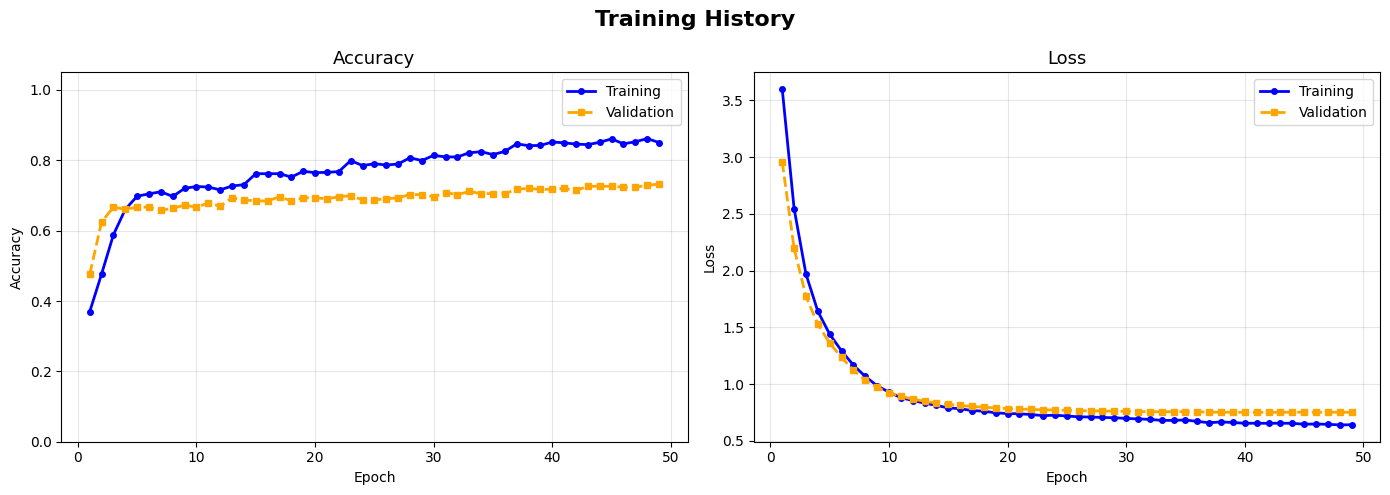

Plot saved as 'training_history.png'


In [ ]:
#visualizing  trained data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
axes[0].plot(epochs_ran, history.history['accuracy'], 'b-o', label='Training', linewidth=2, markersize=4)
axes[0].plot(epochs_ran, history.history['val_accuracy'], 'orange', marker='s', linestyle='--', label='Validation', linewidth=2, markersize=4)
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Loss plot
axes[1].plot(epochs_ran, history.history['loss'], 'b-o', label='Training', linewidth=2, markersize=4)
axes[1].plot(epochs_ran, history.history['val_loss'], 'orange', marker='s', linestyle='--', label='Validation', linewidth=2, markersize=4)
axes[1].set_title('Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'training_history.png'")

In [ ]:
#khadija
# testing model on unseen data and checking accuracy + per class scores

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)  # pick class with highest probability

acc = accuracy_score(y_test, y_pred)

print("=" * 65)
print("PERFORMANCE EVALUATION ON TEST SET")
print("=" * 65)
print(f"\nOverall Accuracy: {acc:.4f}  ({acc*100:.2f}%)")

print("\nDetailed Classification Report:")
print("-" * 65)
print(classification_report(
    y_test, y_pred,
    target_names=labelEncoder.classes_
))
print("precision: accuracy when predicting a class")
print("recall:    how many actual instances we caught")
print("f1-score:  main metric, balances precision and recall")


PERFORMANCE EVALUATION ON TEST SET

Overall Accuracy: 0.7000  (70.00%)

Detailed Classification Report:
-----------------------------------------------------------------
              precision    recall  f1-score   support

 Action Item       0.95      0.94      0.94       140
    Decision       0.59      0.64      0.61       140
  Discussion       0.56      0.53      0.55       140

    accuracy                           0.70       420
   macro avg       0.70      0.70      0.70       420
weighted avg       0.70      0.70      0.70       420

precision: accuracy when predicting a class
recall:    how many actual instances we caught
f1-score:  main metric, balances precision and recall


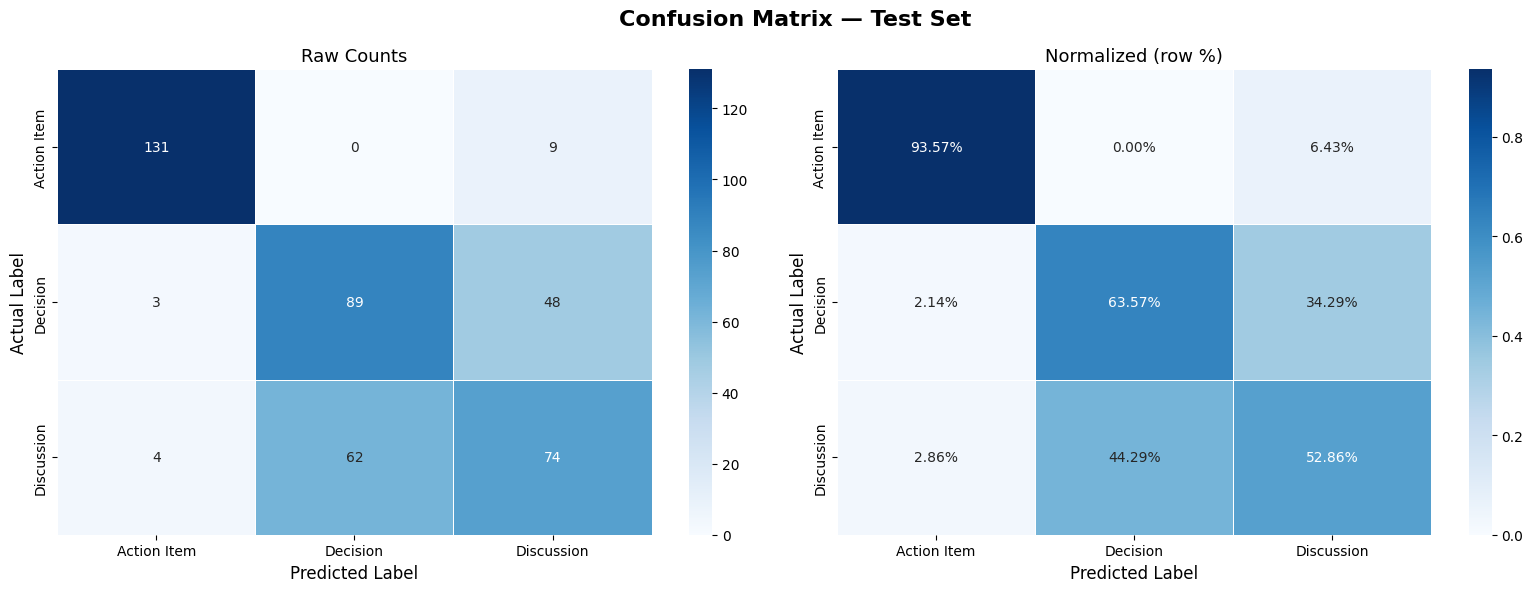

In [ ]:
#khadija
# confusion matrix shows where the model is right and where it makes mistakes
# diagonal = correct predictions, off-diagonal = errors

cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row percentages

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — Test Set', fontsize=16, fontweight='bold')

# raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labelEncoder.classes_,
            yticklabels=labelEncoder.classes_,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Raw Counts', fontsize=13)
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# normalized percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labelEncoder.classes_,
            yticklabels=labelEncoder.classes_,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Normalized (row %)', fontsize=13)
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
#khadija
# loading MeetingBank for the summarization part
# has real city council transcripts with official meeting minutes

from nltk.tokenize import sent_tokenize

meetingbank = load_dataset("huuuyeah/meetingbank")

print(f"Splits: {list(meetingbank.keys())}")
print(f"Train records: {len(meetingbank['train'])}")

cols = meetingbank['train'].column_names
print(f"Columns: {cols}")

# column name varies across dataset versions
transcript_col = 'transcript' if 'transcript' in cols else 'transcripts'
summary_col    = 'summary'    if 'summary'    in cols else None

sample_mb = meetingbank['train'][0]
print(f"\nTranscript snippet:")
print(sample_mb[transcript_col][:500])
if summary_col:
    print(f"\nOfficial minutes: {sample_mb[summary_col][:300]}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.json:   0%|          | 0.00/88.4M [00:00<?, ?B/s]

validation.json:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

test.json:   0%|          | 0.00/13.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5169 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/861 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/862 [00:00<?, ? examples/s]

Splits: ['train', 'validation', 'test']
Train records: 5169
Columns: ['summary', 'uid', 'id', 'transcript']

Transcript snippet:
Please refrain from profane or obscene speech. Direct your comments to council as a whole and refrain from individual or personal attacks. Councilwoman Gilmore, will you please put Council Bill 161 on the floor? Yes, President Brooks, I move that council bill 161 as amended, be placed upon final consideration and do pass. It has been moved and seconded. Councilman. Clerk, go ahead and offer your motion to further amend. Thank you, Mr. President. I move that council bill 161 as amended be further

Official minutes: AS AMENDED a bill for an ordinance amending the Denver Zoning Code to revise parking exemptions for pre-existing small zone lots. Approves a text amendment to the Denver Zoning Code to revise the Pre-Existing Small Zone Lot parking exemption. The Committee approved filing this bill at its meeting on
